In [ ]:
# Machine Learning
# Aim - To classify Mushrooms as Edible (e) or Poisonous (p) based on their
# physical characteristics such as Cap Shape, Cap Surface, Cap Color, Odor,
# Gill Attachment, Stalk Shape, Habitat, etc.

# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [ ]:
# loading data set
df = pd.read_csv('/Datasets/mushroom_classification.csv')
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [ ]:
# Data Information Gathering
# shape
df.shape

(8124, 23)

In [ ]:
# info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [ ]:
# count - Count non-NA cells for each column
df.count()

class                       8124
cap-shape                   8124
cap-surface                 8124
cap-color                   8124
bruises                     8124
odor                        8124
gill-attachment             8124
gill-spacing                8124
gill-size                   8124
gill-color                  8124
stalk-shape                 8124
stalk-root                  8124
stalk-surface-above-ring    8124
stalk-surface-below-ring    8124
stalk-color-above-ring      8124
stalk-color-below-ring      8124
veil-type                   8124
veil-color                  8124
ring-number                 8124
ring-type                   8124
spore-print-color           8124
population                  8124
habitat                     8124
dtype: int64

In [ ]:
# head
df.head(2)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g


In [ ]:
# tail
df.tail(2)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [ ]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [ ]:
# unique classes
df['class'].unique()

<ArrowStringArray>
['p', 'e']
Length: 2, dtype: str

In [ ]:
df['class'].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

In [ ]:
# Data Cleaning
# null values
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [ ]:
# duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


<Axes: xlabel='class', ylabel='count'>

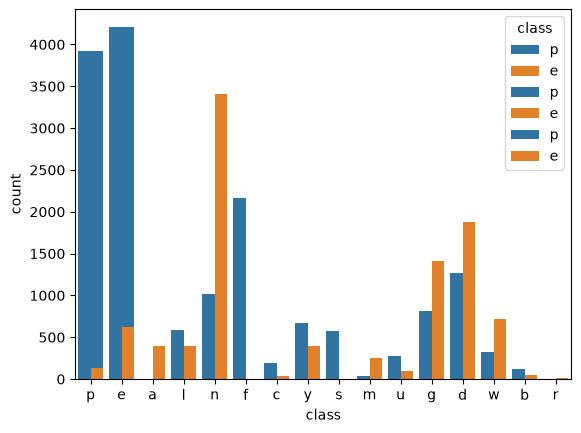

In [ ]:
# Data Visualization
import seaborn as sns
sns.countplot(x='class', data=df)
sns.countplot(x='odor', hue='class', data=df)
sns.countplot(x='habitat', hue='class', data=df)
sns.countplot(x='cap-color', hue='class', data=df)

In [ ]:


# Encoding Categorical Data
# All columns in this dataset are categorical, so we use Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,3,2,4,0,5,0,0,0,11,...,2,5,5,0,1,1,4,0,1,2
8120,0,5,2,4,0,5,0,0,0,11,...,2,5,5,0,0,1,4,0,4,2
8121,0,2,2,4,0,5,0,0,0,5,...,2,5,5,0,1,1,4,0,1,2
8122,1,3,3,4,0,8,1,0,1,0,...,1,7,7,0,2,1,0,7,4,2


<Axes: >

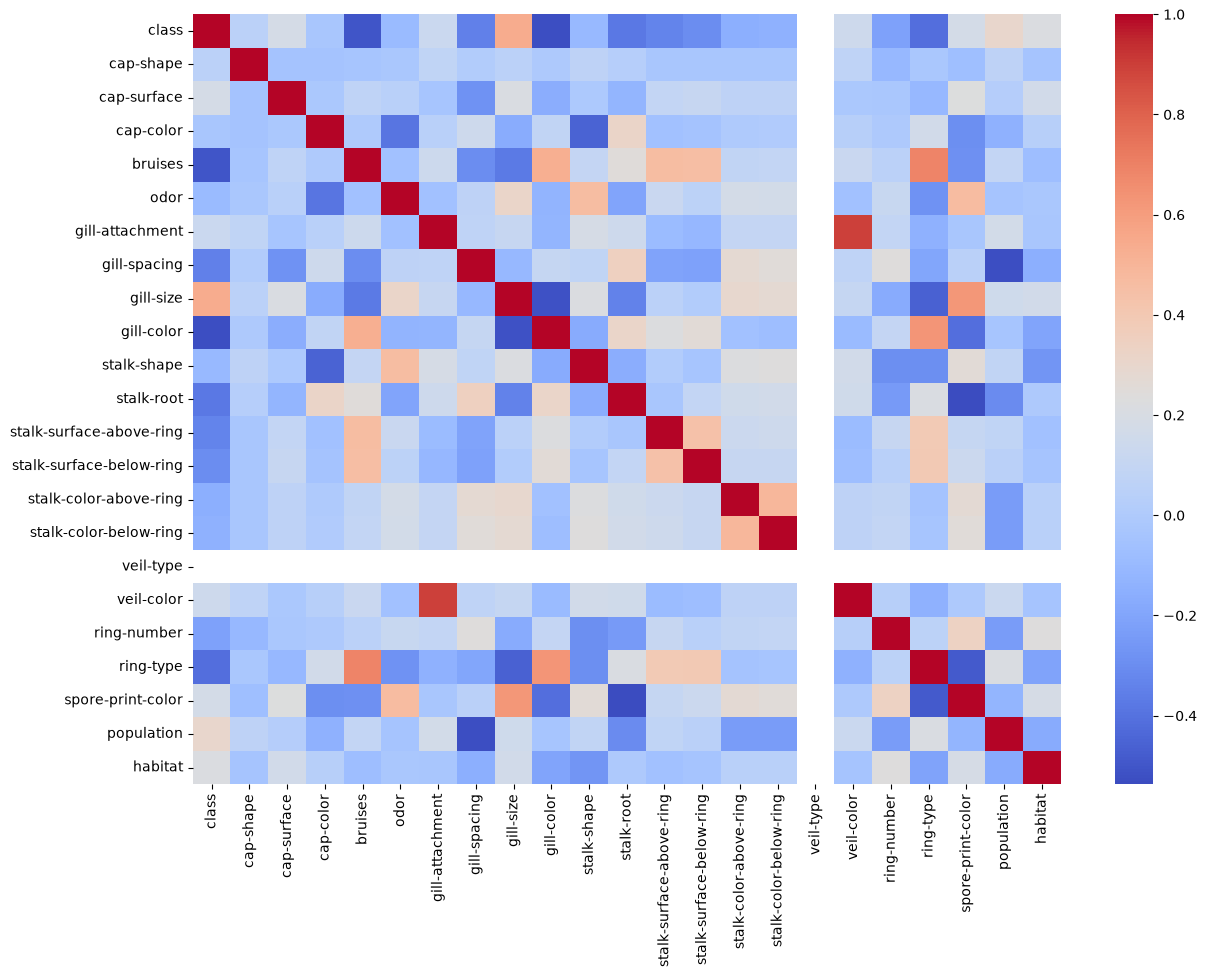

In [ ]:


# correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')



In [ ]:

# Split X and Y
X = df_encoded.drop('class', axis=1)
Y = df_encoded['class']



In [ ]:

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [ ]:
X_train

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
7873,3,2,2,0,7,1,0,1,0,1,...,1,6,7,0,2,1,0,7,4,0
6515,5,2,4,0,2,1,0,1,0,1,...,2,7,7,0,2,1,0,7,4,4
6141,2,3,2,0,8,1,0,1,0,1,...,2,6,7,0,2,1,0,7,4,2
2764,2,0,4,1,5,1,0,0,9,1,...,2,3,6,0,2,1,4,3,4,0
438,0,3,9,1,3,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5226,5,3,4,0,2,1,0,1,0,1,...,2,6,7,0,2,1,0,7,4,4
5390,3,3,2,1,5,1,0,0,10,0,...,2,7,2,0,2,2,0,7,1,6
860,2,3,4,1,3,1,0,0,10,0,...,3,7,7,0,2,1,4,3,5,4
7603,3,2,2,0,2,1,0,1,0,1,...,2,6,6,0,2,1,0,7,4,4


In [ ]:
X_test

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
1971,2,0,4,0,5,1,1,0,3,1,...,0,7,7,0,2,1,0,3,3,1
6654,2,2,2,0,8,1,0,1,0,1,...,2,6,6,0,2,1,0,7,4,2
5606,5,3,4,0,2,1,0,1,0,1,...,2,7,6,0,2,1,0,7,4,2
3332,2,3,3,1,5,1,0,0,5,1,...,2,3,6,0,2,1,4,3,5,0
6988,2,2,2,0,7,1,0,1,0,1,...,2,6,6,0,2,1,0,7,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7374,3,2,2,0,2,1,0,1,0,1,...,2,6,7,0,2,1,0,7,4,4
1149,2,2,4,0,5,1,1,0,3,1,...,2,7,7,0,2,1,0,2,0,1
4999,5,3,4,0,2,1,0,1,0,1,...,1,6,6,0,2,1,0,7,4,4
7497,3,3,4,0,8,1,0,1,0,1,...,1,6,6,0,2,1,0,7,4,4


In [ ]:
y_train

7873    1
6515    1
6141    1
2764    0
438     0
       ..
5226    1
5390    0
860     0
7603    1
7270    0
Name: class, Length: 6499, dtype: int64

In [ ]:
y_test

1971    0
6654    1
5606    1
3332    0
6988    1
       ..
7374    1
1149    0
4999    1
7497    1
3341    1
Name: class, Length: 1625, dtype: int64

In [ ]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_test

array([[-0.85633705, -1.4913458 , -0.19967591, ..., -0.25581597,
        -0.50697399, -0.29694568],
       [-0.85633705,  0.1369207 , -0.98259822, ...,  1.41971739,
         0.2873423 ,  0.28328582],
       [ 1.01940764,  0.95105395, -0.19967591, ...,  1.41971739,
         0.2873423 ,  0.28328582],
       ...,
       [ 1.01940764,  0.95105395, -0.19967591, ...,  1.41971739,
         0.2873423 ,  1.44374884],
       [-0.23108882,  0.95105395, -0.19967591, ...,  1.41971739,
         0.2873423 ,  1.44374884],
       [ 1.01940764, -1.4913458 ,  1.75762986, ..., -1.09358265,
         1.08165859,  1.44374884]], shape=(1625, 22))

In [ ]:

# Building, Training and Testing Model
# Algorithm 1 - Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

classifier_LR = LogisticRegression()

classifier_LR.fit(X_train, y_train)

y_pred = classifier_LR.predict(X_test)

S_LR = accuracy_score(y_test, y_pred)
print(S_LR)

# Predicting the Model
# sample input -> first row of X_test
P_LR = classifier_LR.predict(X_test[[0]])
P_LR

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Logistic Regression'],
                  'Accuracy': [S_LR],
                  'Actual1': [y_test.iloc[0]],
                  'Prediction1': [P_LR]})
a

0.952


,Algorithm,Accuracy,Actual1,Prediction1
0,Logistic Regression,0.952,0,[0]


In [ ]:

# Algorithm 2 - Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create the model
classifier_DT = DecisionTreeClassifier(random_state=42)

# Train the model
classifier_DT.fit(X_train, y_train)

# Make predictions
y_pred = classifier_DT.predict(X_test)

# Calculate Accuracy
S_DT = accuracy_score(y_test, y_pred)

# Print the score
print("Accuracy:", S_DT)

P_DT = classifier_DT.predict(X_test[[0]])
P_DT

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Logistic Regression', 'Decision Tree Classifier'],
                  'Accuracy': [S_LR, S_DT],
                  'Actual1': [y_test.iloc[0], y_test.iloc[0]],
                  'Prediction1': [P_LR, P_DT]})
a

Accuracy: 1.0


,Algorithm,Accuracy,Actual1,Prediction1
0,Logistic Regression,0.952,0,[0]
1,Decision Tree Classifier,1.000,0,[0]


In [ ]:

# Algorithm 3 - Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create the model
classifier_RF = RandomForestClassifier(random_state=42)

# Train the model
classifier_RF.fit(X_train, y_train)

# Make predictions
y_pred = classifier_RF.predict(X_test)

# Calculate Accuracy
S_RF = accuracy_score(y_test, y_pred)

# Print the score
print("Accuracy:", S_RF)

P_RF = classifier_RF.predict(X_test[[0]])
P_RF

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Logistic Regression', 'Decision Tree Classifier', 'Random Forest Classifier'],
                  'Accuracy': [S_LR, S_DT, S_RF],
                  'Actual1': [y_test.iloc[0], y_test.iloc[0], y_test.iloc[0]],
                  'Prediction1': [P_LR, P_DT, P_RF]})
a

Accuracy: 1.0


,Algorithm,Accuracy,Actual1,Prediction1
0,Logistic Regression,0.952,0,[0]
1,Decision Tree Classifier,1.000,0,[0]
2,Random Forest Classifier,1.000,0,[0]


In [ ]:

# Algorithm 4 - Support Vector Classifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create the model
classifier_SVC = SVC()

# Train the model
classifier_SVC.fit(X_train, y_train)

# Make predictions
y_pred = classifier_SVC.predict(X_test)

# Calculate Accuracy
S_SVC = accuracy_score(y_test, y_pred)

# Print the score
print("Accuracy:", S_SVC)

P_SVC = classifier_SVC.predict(X_test[[0]])
P_SVC

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Logistic Regression', 'Decision Tree Classifier', 'Random Forest Classifier', 'Support Vector Machine Classifier'],
                  'Accuracy': [S_LR, S_DT, S_RF, S_SVC],
                  'Actual1': [y_test.iloc[0], y_test.iloc[0], y_test.iloc[0], y_test.iloc[0]],
                  'Prediction1': [P_LR, P_DT, P_RF, P_SVC]})
a

Accuracy: 1.0


,Algorithm,Accuracy,Actual1,Prediction1
0,Logistic Regression,0.952,0,[0]
1,Decision Tree Classifier,1.000,0,[0]
2,Random Forest Classifier,1.000,0,[0]
3,Support Vector Machine Classifier,1.000,0,[0]


In [ ]:

# Algorithm 5 - KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create the model
classifier_KNN = KNeighborsClassifier()

# Train the model
classifier_KNN.fit(X_train, y_train)

# Make predictions
y_pred = classifier_KNN.predict(X_test)

# Calculate Accuracy
S_KNN = accuracy_score(y_test, y_pred)

# Print the score
print("Accuracy:", S_KNN)

P_KNN = classifier_KNN.predict(X_test[[0]])
P_KNN

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Logistic Regression', 'Decision Tree Classifier', 'Random Forest Classifier', 'Support Vector Machine Classifier', 'KNC'],
                  'Accuracy': [S_LR, S_DT, S_RF, S_SVC, S_KNN],
                  'Actual1': [y_test.iloc[0], y_test.iloc[0], y_test.iloc[0], y_test.iloc[0], y_test.iloc[0]],
                  'Prediction1': [P_LR, P_DT, P_RF, P_SVC, P_KNN]})
a

Accuracy: 1.0


,Algorithm,Accuracy,Actual1,Prediction1
0,Logistic Regression,0.952,0,[0]
1,Decision Tree Classifier,1.000,0,[0]
2,Random Forest Classifier,1.000,0,[0]
3,Support Vector Machine Classifier,1.000,0,[0]
4,KNC,1.000,0,[0]


In [ ]:

# Algorithm 6 - Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Create the model
classifier_GB = GradientBoostingClassifier(random_state=42)

# Train the model
classifier_GB.fit(X_train, y_train)

# Make predictions
y_pred = classifier_GB.predict(X_test)

# Calculate Accuracy
S_GB = accuracy_score(y_test, y_pred)

# Print the score
print("Accuracy:", S_GB)

P_GB = classifier_GB.predict(X_test[[0]])
P_GB

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Logistic Regression', 'Decision Tree Classifier', 'Random Forest Classifier', 'Support Vector Machine Classifier', 'KNC', 'Gradient Boosting Classifier'],
                  'Accuracy': [S_LR, S_DT, S_RF, S_SVC, S_KNN, S_GB],
                  'Actual1': [y_test.iloc[0], y_test.iloc[0], y_test.iloc[0], y_test.iloc[0], y_test.iloc[0], y_test.iloc[0]],
                  'Prediction1': [P_LR, P_DT, P_RF, P_SVC, P_KNN, P_GB]})
a

Accuracy: 1.0


,Algorithm,Accuracy,Actual1,Prediction1
0,Logistic Regression,0.952,0,[0]
1,Decision Tree Classifier,1.000,0,[0]
2,Random Forest Classifier,1.000,0,[0]
3,Support Vector Machine Classifier,1.000,0,[0]
4,KNC,1.000,0,[0]
5,Gradient Boosting Classifier,1.000,0,[0]


In [ ]:
# Algorithm 6 - Gradient Boosting Classifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Create the model
classifier_GNB = GaussianNB()

# Train the model
classifier_GNB.fit(X_train, y_train)

# Make predictions
y_pred = classifier_GNB.predict(X_test)

# Calculate Accuracy
S_GNB = accuracy_score(y_test, y_pred)

# Print the score
print("Accuracy:", S_GNB)

P_GNB = classifier_GB.predict(X_test[[0]])
P_GNB

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Logistic Regression', 'Decision Tree Classifier', 'Random Forest Classifier', 'Support Vector Machine Classifier', 'KNC', 'Gradient Boosting Classifier', 'GaussianNB'],
                  'Accuracy': [S_LR, S_DT, S_RF, S_SVC, S_KNN, S_GB, S_GNB],
                  'Actual1': [y_test.iloc[0], y_test.iloc[0], y_test.iloc[0], y_test.iloc[0], y_test.iloc[0], y_test.iloc[0], y_test.iloc[0]],
                  'Prediction1': [P_LR, P_DT, P_RF, P_SVC, P_KNN, P_GB, P_GNB]})
a

Accuracy: 0.9218461538461539


,Algorithm,Accuracy,Actual1,Prediction1
0,Logistic Regression,0.952000,0,[0]
1,Decision Tree Classifier,1.000000,0,[0]
2,Random Forest Classifier,1.000000,0,[0]
3,Support Vector Machine Classifier,1.000000,0,[0]
4,KNC,1.000000,0,[0]
5,Gradient Boosting Classifier,1.000000,0,[0]
6,GaussianNB,0.921846,0,[0]


In [ ]:

# Prediction Comparison with Accuracy Score


actual_values = [y_test.iloc[0], y_test.iloc[1], y_test.iloc[2]]

LR_prediction = classifier_LR.predict(X_test[[0, 1, 2]])
DT_prediction = classifier_DT.predict(X_test[[0, 1, 2]])
RF_prediction = classifier_RF.predict(X_test[[0, 1, 2]])
SVC_prediction = classifier_SVC.predict(X_test[[0, 1, 2]])
KNN_prediction = classifier_KNN.predict(X_test[[0, 1, 2]])
GB_prediction = classifier_GB.predict(X_test[[0, 1, 2]])
GNB_prediction = classifier_GNB.predict(X_test[[0, 1, 2]])


comparison = pd.DataFrame({

    'Actual Class': [
        'Accuracy Score',
        actual_values[0],
        actual_values[1],
        actual_values[2]
    ],


    'Logistic Regression': [
        S_LR,
        LR_prediction[0],
        LR_prediction[1],
        LR_prediction[2]
    ],


    'Decision Tree Classifier': [
        S_DT,
        DT_prediction[0],
        DT_prediction[1],
        DT_prediction[2]
    ],


    'Random Forest Classifier': [
        S_RF,
        RF_prediction[0],
        RF_prediction[1],
        RF_prediction[2]
    ],


    'SVC': [
        S_SVC,
        SVC_prediction[0],
        SVC_prediction[1],
        SVC_prediction[2]
    ],


    'KNC': [
        S_KNN,
        KNN_prediction[0],
        KNN_prediction[1],
        KNN_prediction[2]
    ],


    'Gradient Boosting Classifier': [
        S_GB,
        GB_prediction[0],
        GB_prediction[1],
        GB_prediction[2]
    ],

    'GaussianNB': [
        S_GNB,
        GNB_prediction[0],
        GNB_prediction[1],
        GNB_prediction[2]
    ]

})


comparison.index = [
    'Accuracy Score',
    'Sample 1',
    'Sample 2',
    'Sample 3'
]


comparison


,Actual Class,Logistic Regression,Decision Tree Classifier,Random Forest Classifier,SVC,KNC,Gradient Boosting Classifier,GaussianNB
Accuracy Score,Accuracy Score,0.952,1.0,1.0,1.0,1.0,1.0,0.921846
Sample 1,0,0.000,0.0,0.0,0.0,0.0,0.0,0.000000
Sample 2,1,1.000,1.0,1.0,1.0,1.0,1.0,1.000000
Sample 3,1,1.000,1.0,1.0,1.0,1.0,1.0,1.000000
